In [1]:
packages = ["sklearn", "mlflow", "shap", "mlxtend"]

for pkg in packages:
    try:
        module = __import__(pkg)
        version = getattr(module, "__version__", "unknown version")
        print(f"{pkg}: installed ({version})")
    except ImportError:
        print(f"{pkg}: NOT installed")

sklearn: installed (1.7.2)
mlflow: NOT installed
shap: NOT installed
mlxtend: NOT installed


In [1]:
packages = ["sklearn", "mlflow", "shap", "mlxtend"]

for pkg in packages:
    try:
        module = __import__(pkg)
        version = getattr(module, "__version__", "unknown version")
        print(f"{pkg}: installed ({version})")
    except ImportError:
        print(f"{pkg}: NOT installed")

sklearn: installed (1.9.1)
mlflow: installed (3.16.0)
shap: installed (0.52.0)
mlxtend: installed (0.25.0)


### Part 3 Setup: Reuse Part 2's Pipeline and Feature Engineering

Part 3 builds directly on Part 2's cleaned, feature-engineered dataset rather than
reloading/recleaning the raw CSV independently — same reuse pattern as
`visualizations.py` and `traffic_cli.py` importing from `pipeline.py` and
`feature_engineering.py`, just now reaching one directory further up from
`part3_machine_learning/notebooks/`.

In [2]:
import sys
from pathlib import Path

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent  # notebooks -> part3_machine_learning -> project root
PART2_DIR = PROJECT_ROOT / "part2_python"
sys.path.insert(0, str(PART2_DIR))

from pipeline import run_pipeline, DATA_FILE
from feature_engineering import engineer_features

clean_df = run_pipeline(DATA_FILE)
feat_df = engineer_features(clean_df)
feat_df.shape

Standardised casing to lowercase in 1730 rows of 'weather_description' (merging case-variant duplicates such as 'Sky is Clear' / 'sky is clear').
Removed 17 exact duplicate rows.
Collapsed 5430 duplicate-timestamp hours (7612 rows removed) down to one row per hour; 0 of these hours had inconsistent traffic_volume across duplicates.
Found 10 rows with physically impossible 'temp' readings (<= 0 Kelvin).
Found 1 rows with physically implausible 'rain_1h' readings (> 1000mm/hour): [9831.3]
Imputed 4 missing 'temp' value(s) in month 1 using that month's median (265.48).
Imputed 6 missing 'temp' value(s) in month 2 using that month's median (265.89).
Imputed 1 missing 'rain_1h' value(s) in month 7 using that month's median (0.00).


(40575, 29)

### Proxy Accident-Risk Label

No accident dataset exists, so we build a documented proxy `high_risk` label per the brief.

**`SEVERE_WEATHER`** reuses the exact same definition as Part 2's `is_severe_weather` flag
(`Thunderstorm`, `Squall`), for consistency across the whole project.

**`is_low_visibility`** is new: weather conditions that impair visibility —
`Fog`, `Mist`, `Haze`, `Smoke`.

**Congestion bucketing for this label uses 4 categories** (Low/Medium/High/Severe, split on
the 25th/50th/75th percentiles), which is different from Part 2's `congestion_category`
(3 categories, split on 25th/75th only). To avoid overwriting or confusing Part 2's column,
this one is named `risk_congestion_category` and lives only in Part 3.

A row is `high_risk` when High/Severe congestion coincides with severe or low-visibility
weather.

In [3]:
import numpy as np

SEVERE_WEATHER = ["Thunderstorm", "Squall"]
LOW_VISIBILITY_CONDITIONS = ["Fog", "Mist", "Haze", "Smoke"]

feat_df["is_low_visibility"] = feat_df["weather_main"].isin(LOW_VISIBILITY_CONDITIONS).astype(int)

# Congestion category (data-driven quartiles of traffic_volume) — 4 buckets, used only
# to construct the proxy risk label, distinct from Part 2's 3-bucket congestion_category
q1, q2, q3 = feat_df["traffic_volume"].quantile([0.25, 0.5, 0.75]).values

def bucket(v):
    if v <= q1:
        return "Low"
    elif v <= q2:
        return "Medium"
    elif v <= q3:
        return "High"
    return "Severe"

feat_df["risk_congestion_category"] = feat_df["traffic_volume"].apply(bucket)

# Proxy accident-risk label
high_congestion = feat_df["risk_congestion_category"].isin(["High", "Severe"])
risky_weather = (
    feat_df["weather_main"].isin(SEVERE_WEATHER)
    | (feat_df["is_low_visibility"] == 1)
)
feat_df["high_risk"] = (high_congestion & risky_weather).astype(int)

print(feat_df["risk_congestion_category"].value_counts())
print()
print(feat_df["is_low_visibility"].value_counts())
print()
print(feat_df["high_risk"].value_counts())
print(feat_df["high_risk"].value_counts(normalize=True))

risk_congestion_category
High      10145
Medium    10144
Low       10144
Severe    10142
Name: count, dtype: int64

is_low_visibility
0    36524
1     4051
Name: count, dtype: int64

high_risk
0    38649
1     1926
Name: count, dtype: int64
high_risk
0    0.952532
1    0.047468
Name: proportion, dtype: float64


### Completing the Common Feature Set for Task 1

Two pieces the brief requires that we don't have yet:
- **Holiday flag**: `holiday` is currently NaN for non-holidays and a holiday's name (e.g. 'Labor Day') otherwise — not usable as a numeric model input directly. We convert it to a clean binary `is_holiday`.
- **Cyclical encoding of day of week**: Part 2 only cyclically encoded hour (`hour_sin`/`hour_cos`). Adding `dow_sin`/`dow_cos` the same way (period 7 instead of 24) captures that Sunday (6) and Monday (0) are adjacent, not far apart.

In [4]:
feat_df["is_holiday"] = feat_df["holiday"].notna().astype(int)

feat_df["dow_sin"] = np.sin(2 * np.pi * feat_df["day_of_week"] / 7)
feat_df["dow_cos"] = np.cos(2 * np.pi * feat_df["day_of_week"] / 7)

print(feat_df["is_holiday"].value_counts())
print(feat_df[["day_of_week", "dow_sin", "dow_cos"]].drop_duplicates().sort_values("day_of_week"))

is_holiday
0    40522
1       53
Name: count, dtype: int64
     day_of_week   dow_sin   dow_cos
126            0  0.000000  1.000000
0              1  0.781831  0.623490
15             2  0.974928 -0.222521
35             3  0.433884 -0.900969
59             4 -0.433884 -0.900969
81             5 -0.974928 -0.222521
104            6 -0.781831  0.623490


## Task 1 — Supervised Machine Learning Models

### Step 1: Load the Part 3 dataset and build a chronological train/test split

This cell replaces the earlier prototyping cells (proxy label construction, holiday/day of week encoding) with a single call to the now consolidated `data_prep.py`, so the notebook and the standalone script are always building from the exact same logic rather than two copies that could drift apart.

Because this is genuine hourly time series data spanning October 2012 to September 2018, we deliberately avoid a random train/test split. Shuffling would let a model train on rows that come chronologically after some of its own test points, information a real deployed model would never have at prediction time. Instead we sort by `date_time` and cut at a fixed point in the timeline:

- Everything before the cutoff date becomes the training set.
- Everything from the cutoff date onward becomes the test set.
- The cutoff sits at roughly 80% of the way through the full date range, so the training set is the past and the test set is the most recent slice, the way it would work in production.
- The same split is reused for both models in this task, the `high_risk` classifier and the `traffic_volume` regressor, so both are judged on the same held out period and results stay comparable.

In [5]:
import sys
from pathlib import Path

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PART3_DIR = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PART3_DIR))

from data_prep import prepare_data

ml_df = prepare_data()
ml_df = ml_df.sort_values("date_time").reset_index(drop=True)

split_idx = int(len(ml_df) * 0.8)
cutoff_date = ml_df.loc[split_idx, "date_time"]

train_df = ml_df[ml_df["date_time"] < cutoff_date].copy()
test_df = ml_df[ml_df["date_time"] >= cutoff_date].copy()

print(f"Cutoff date: {cutoff_date}")
print(f"Train: {train_df.shape[0]} rows  ({train_df['date_time'].min()} to {train_df['date_time'].max()})")
print(f"Test:  {test_df.shape[0]} rows  ({test_df['date_time'].min()} to {test_df['date_time'].max()})")
print(f"Train high_risk rate: {train_df['high_risk'].mean():.2%}")
print(f"Test  high_risk rate: {test_df['high_risk'].mean():.2%}")

Standardised casing to lowercase in 1730 rows of 'weather_description' (merging case-variant duplicates such as 'Sky is Clear' / 'sky is clear').
Removed 17 exact duplicate rows.
Collapsed 5430 duplicate-timestamp hours (7612 rows removed) down to one row per hour; 0 of these hours had inconsistent traffic_volume across duplicates.
Found 10 rows with physically impossible 'temp' readings (<= 0 Kelvin).
Found 1 rows with physically implausible 'rain_1h' readings (> 1000mm/hour): [9831.3]
Imputed 4 missing 'temp' value(s) in month 1 using that month's median (265.48).
Imputed 6 missing 'temp' value(s) in month 2 using that month's median (265.89).
Imputed 1 missing 'rain_1h' value(s) in month 7 using that month's median (0.00).


Cutoff date: 2017-10-26 18:00:00
Train: 32460 rows  (2012-10-02 09:00:00 to 2017-10-26 17:00:00)
Test:  8115 rows  (2017-10-26 18:00:00 to 2018-09-30 23:00:00)
Train high_risk rate: 4.59%
Test  high_risk rate: 5.37%


### Diagnostic: why does the test period have a higher high_risk rate?

The proxy label combines a congestion threshold (computed globally, across all years) with a severe or low-visibility weather flag. A higher `high_risk` rate in the test period could come from either component. Grouping by year isolates which one is responsible.

In [6]:
diagnostic = ml_df.copy()
diagnostic["year"] = diagnostic["date_time"].dt.year

yearly_summary = diagnostic.groupby("year").agg(
    avg_traffic_volume=("traffic_volume", "mean"),
    pct_high_or_severe_congestion=("risk_congestion_category", lambda s: s.isin(["High", "Severe"]).mean()),
    pct_severe_weather=("weather_main", lambda s: s.isin(["Thunderstorm", "Squall"]).mean()),
    pct_low_visibility=("is_low_visibility", "mean"),
    pct_high_risk=("high_risk", "mean"),
)

print(yearly_summary.round(4))

      avg_traffic_volume  pct_high_or_severe_congestion  pct_severe_weather  \
year                                                                          
2012           3226.7019                         0.4784              0.0019   
2013           3309.5528                         0.4936              0.0048   
2014           3270.1433                         0.4901              0.0029   
2015           3258.0420                         0.4940              0.0095   
2016           3193.6952                         0.4886              0.0079   
2017           3376.5891                         0.5205              0.0189   
2018           3323.9013                         0.5105              0.0216   

      pct_low_visibility  pct_high_risk  
year                                     
2012              0.1583         0.0737  
2013              0.0893         0.0404  
2014              0.0395         0.0182  
2015              0.1258         0.0509  
2016              0.0981         0.0

### Step 2: Define the feature set for Task 1 models

`high_risk` is derived from `risk_congestion_category` (built from `traffic_volume`) and weather conditions. To avoid leakage, `traffic_volume`, its scaled version, and both congestion category columns are excluded as predictors, since including them would let a model trivially reconstruct the label rather than learn a genuine pattern. Weather encodings and time-based features remain, since those represent information legitimately available at prediction time.

First, list every column in `ml_df` so the include/exclude list below is built against the actual schema, not assumption.

In [7]:
for col in ml_df.columns:
    print(f"{col:30s} {ml_df[col].dtype}")

holiday                        object
temp                           float64
rain_1h                        float64
snow_1h                        float64
clouds_all                     int64
weather_main                   object
weather_description            object
date_time                      datetime64[ns]
traffic_volume                 int64
hour                           int32
day_of_week                    int32
is_weekend                     int64
hour_sin                       float64
hour_cos                       float64
wx_Clear                       int64
wx_Clouds                      int64
wx_Drizzle                     int64
wx_Fog                         int64
wx_Haze                        int64
wx_Mist                        int64
wx_Rain                        int64
wx_Smoke                       int64
wx_Snow                        int64
wx_Squall                      int64
wx_Thunderstorm                int64
is_severe_weather              int64
temp_scaled     

### Step 3: Build the shared feature matrix and both targets

The same 23 engineered features feed both models in this task, only the target differs: `high_risk` for the classifier, `traffic_volume` for the regressor. Building both target vectors alongside a single `FEATURE_COLS` list keeps the two tasks on an identical, leakage-free feature set.

In [8]:
FEATURE_COLS = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_holiday",
    "wx_Clear", "wx_Clouds", "wx_Drizzle", "wx_Fog", "wx_Haze", "wx_Mist",
    "wx_Rain", "wx_Smoke", "wx_Snow", "wx_Squall", "wx_Thunderstorm",
    "is_severe_weather", "is_low_visibility",
    "temp_scaled", "rain_1h", "snow_1h", "clouds_all",
]

X_train, X_test = train_df[FEATURE_COLS], test_df[FEATURE_COLS]

y_train_clf, y_test_clf = train_df["high_risk"], test_df["high_risk"]
y_train_reg, y_test_reg = train_df["traffic_volume"], test_df["traffic_volume"]

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"Missing values in X_train: {X_train.isna().sum().sum()}")
print(f"Missing values in X_test:  {X_test.isna().sum().sum()}")
print(f"\ny_train_clf positive rate: {y_train_clf.mean():.2%}")
print(f"y_test_clf  positive rate: {y_test_clf.mean():.2%}")
print(f"\ny_train_reg mean: {y_train_reg.mean():.1f}   y_test_reg mean: {y_test_reg.mean():.1f}")

X_train: (32460, 23)   X_test: (8115, 23)
Missing values in X_train: 0
Missing values in X_test:  0

y_train_clf positive rate: 4.59%
y_test_clf  positive rate: 5.37%

y_train_reg mean: 3285.9   y_test_reg mean: 3309.6


### Step 4: Fit and evaluate baseline classification models

Two algorithms on the same feature set: logistic regression as the linear baseline, and a random forest as the tree-based ensemble, satisfying the brief's requirement for at least two algorithms.

`high_risk` is a rare event, roughly 5% positive in both splits, so both models use `class_weight="balanced"`. Without it, a classifier could predict "not high risk" for every single row and still score about 95% accuracy while being completely useless, which is exactly why accuracy alone is not reported as the headline metric here. Precision, recall, F1, and ROC AUC are evaluated together instead, since precision and recall trade off directly against each other under class imbalance and neither alone tells the full story.

In [16]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train, y_train_clf)

rf_clf = RandomForestClassifier(
    n_estimators=150, max_depth=15, min_samples_leaf=10,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf_clf.fit(X_train, y_train_clf)

models_clf = {"Logistic Regression": log_reg, "Random Forest": rf_clf}
results_clf = []

for name, model in models_clf.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results_clf.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_clf, y_pred),
        "Precision": precision_score(y_test_clf, y_pred),
        "Recall": recall_score(y_test_clf, y_pred),
        "F1": f1_score(y_test_clf, y_pred),
        "ROC AUC": roc_auc_score(y_test_clf, y_proba),
    })

results_clf_df = pd.DataFrame(results_clf).set_index("Model")
print(results_clf_df.round(4))

                     Accuracy  Precision  Recall      F1  ROC AUC
Model                                                            
Logistic Regression    0.9784     0.7136     1.0  0.8329   0.9978
Random Forest          0.9890     0.8305     1.0  0.9074   0.9988


### Step 5: Fit and evaluate baseline regression models

Same feature set, same train/test split, new target: `traffic_volume`. Linear regression as the baseline, random forest regressor as the tree-based ensemble, evaluated with MAE (mean absolute error, in the same units as traffic volume, easy to interpret directly) and R-squared (the proportion of variance explained).

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_reg)

rf_reg = RandomForestRegressor(
    n_estimators=150, max_depth=15, min_samples_leaf=10,
    random_state=42, n_jobs=-1,
)
rf_reg.fit(X_train, y_train_reg)

models_reg = {"Linear Regression": lin_reg, "Random Forest": rf_reg}
results_reg = []

for name, model in models_reg.items():
    y_pred = model.predict(X_test)
    results_reg.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_reg, y_pred),
        "R2": r2_score(y_test_reg, y_pred),
    })

results_reg_df = pd.DataFrame(results_reg).set_index("Model")
print(results_reg_df.round(4))

                        MAE      R2
Model                              
Linear Regression  828.2493  0.7089
Random Forest      268.7806  0.9411


### Step 6: Feature importance from the random forest models

Random forest exposes `feature_importances_` directly (mean decrease in impurity across all trees), giving a quick, model-native view of which features drive each prediction. This is a useful sanity check on its own, does the ranking match domain intuition, and it foreshadows the SHAP-based explainability required later in Task 3.

In [18]:
importances_clf = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
importances_reg = pd.Series(rf_reg.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

print("Top 8 features — high_risk classifier:")
print(importances_clf.head(8).round(4))

print("\nTop 8 features — traffic_volume regressor:")
print(importances_reg.head(8).round(4))

Top 8 features — high_risk classifier:
is_low_visibility    0.3720
hour_cos             0.1271
wx_Mist              0.1213
wx_Clouds            0.0886
wx_Clear             0.0621
wx_Haze              0.0551
is_severe_weather    0.0408
wx_Thunderstorm      0.0357
dtype: float64

Top 8 features — traffic_volume regressor:
hour_cos       0.6917
hour_sin       0.1814
dow_sin        0.0531
is_weekend     0.0499
temp_scaled    0.0129
dow_cos        0.0064
clouds_all     0.0023
wx_Clouds      0.0007
dtype: float64


## Task 2 — Unsupervised Machine Learning


### Step 1: Build a weather severity feature and prepare the clustering feature set

The brief asks for clustering on hour, weather severity, and traffic volume. `weather_main` already exists as 11 unordered categories, useful for one-hot encoding but not directly usable as a single ordered "severity" scale for clustering. So we build one explicitly: an ordinal `weather_severity` column (0 = Clear, rising through cloud cover, low visibility, precipitation, up to 5 = severe storms). Like `high_risk` earlier, this is a designed proxy rather than a value present in the raw data, and is documented as one here for the same reason.

Since K-means is distance based, every input needs to sit on a comparable scale, otherwise `traffic_volume` (ranging into the thousands) would dominate the distance calculation over `weather_severity` (0 to 5) or the hour cyclical encoding (-1 to 1). Hour uses the existing `hour_sin`/`hour_cos` pair rather than raw `hour`, keeping 23:00 and 00:00 adjacent, consistent with every other place in this project that touches hour. All four inputs are standardised together with one scaler.

In [19]:
from sklearn.preprocessing import StandardScaler

WEATHER_SEVERITY_RANK = {
    "Clear": 0,
    "Clouds": 1,
    "Mist": 2, "Haze": 2, "Smoke": 2, "Fog": 2,
    "Drizzle": 3, "Rain": 3,
    "Snow": 4,
    "Thunderstorm": 5, "Squall": 5,
}

cluster_df = ml_df.copy()
cluster_df["weather_severity"] = cluster_df["weather_main"].map(WEATHER_SEVERITY_RANK)

print(cluster_df["weather_severity"].value_counts().sort_index())

unmapped = cluster_df["weather_main"][cluster_df["weather_severity"].isna()].unique()
print(f"\nUnmapped weather_main values (should be empty): {unmapped}")

CLUSTER_FEATURES = ["hour_sin", "hour_cos", "weather_severity", "traffic_volume"]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[CLUSTER_FEATURES])

print(f"\nX_cluster shape: {X_cluster.shape}")
print(f"Feature means (should be ~0): {X_cluster.mean(axis=0).round(4)}")
print(f"Feature stds (should be ~1): {X_cluster.std(axis=0).round(4)}")

weather_severity
0    13366
1    15123
2     4051
3     5284
4     2297
5      454
Name: count, dtype: int64

Unmapped weather_main values (should be empty): []

X_cluster shape: (40575, 4)
Feature means (should be ~0): [ 0. -0.  0. -0.]
Feature stds (should be ~1): [1. 1. 1. 1.]


### Step 2: Choose the number of clusters

K-means needs k chosen in advance, so we sweep a range of values and look at two diagnostics together: inertia (within-cluster sum of squared distances, which always decreases as k grows, so we look for an elbow, the point where adding another cluster stops buying much) and silhouette score (how well separated and internally consistent the clusters are, from -1 to 1, higher is better).

Silhouette score is expensive to compute exactly on 40,575 rows (it needs pairwise distances between every point), so it is computed on a random sample of 5,000 rows each time, that keeps it fast while still giving a reliable read on cluster quality.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels, sample_size=5000, random_state=42)
    inertias.append(km.inertia_)
    silhouettes.append(sil)
    print(f"k={k}: inertia={km.inertia_:9.1f}   silhouette={sil:.4f}")

k=2: inertia= 101257.2   silhouette=0.3612
k=3: inertia=  79098.8   silhouette=0.3288
k=4: inertia=  64743.7   silhouette=0.3354
k=5: inertia=  52900.0   silhouette=0.3331
k=6: inertia=  42626.2   silhouette=0.3563
k=7: inertia=  37242.7   silhouette=0.3672
k=8: inertia=  33477.5   silhouette=0.3579


### Step 3: Fit the final model and profile each cluster

k=6 chosen: near-peak silhouette (0.3563 vs. the 0.3672 peak at k=7, a difference well within the noise of a 5,000-row silhouette sample), sitting at the point on the inertia curve where returns start diminishing, and a manageable number of segments to interpret distinctly.

Clustering itself uses the standardised features (`X_cluster`), but interpretation uses the original, human-readable columns, average hour, average weather severity, the most common weather condition, percentage of weekend rows, and average traffic volume, per cluster.

In [21]:
FINAL_K = 6

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans_final.fit_predict(X_cluster)

cluster_profile = cluster_df.groupby("cluster").agg(
    n_rows=("cluster", "size"),
    avg_hour=("hour", "mean"),
    avg_weather_severity=("weather_severity", "mean"),
    most_common_weather=("weather_main", lambda s: s.mode()[0]),
    pct_weekend=("is_weekend", "mean"),
    avg_traffic_volume=("traffic_volume", "mean"),
)
cluster_profile["pct_of_data"] = (cluster_profile["n_rows"] / len(cluster_df) * 100).round(2)

print(cluster_profile.round(2))

         n_rows  avg_hour  avg_weather_severity most_common_weather  \
cluster                                                               
0          8617      3.01                  0.65               Clear   
1          7815     15.47                  0.71              Clouds   
2          8460      9.20                  0.77              Clouds   
3          6847     20.84                  0.58              Clouds   
4          4383     12.44                  3.31                Rain   
5          4453     10.18                  3.24                Rain   

         pct_weekend  avg_traffic_volume  pct_of_data  
cluster                                                
0               0.35              878.48        21.24  
1               0.28             5131.91        19.26  
2               0.23             4814.45        20.85  
3               0.30             2579.85        16.87  
4               0.23             4834.19        10.80  
5               0.30             1405.7

### Step 4: Discretise variables for association rule mining

Apriori needs categorical "items," not continuous values, so hour, weather, weekday type, and congestion each get bucketed. Reusing already-documented definitions where they exist, rather than inventing new ones, keeps the project internally consistent:

- `time_of_day`: Night (00-05), Morning Rush (06-09), Midday (10-15), Evening Rush (16-19), Evening (20-23), chosen to isolate the two commute peaks already established in Part 2.
- `weather_bucket`: Severe and LowVisibility reuse the exact `SEVERE_WEATHER`/`LOW_VISIBILITY_CONDITIONS` lists from `data_prep.py`; Precipitation groups Rain/Drizzle/Snow; the rest are Clouds or Clear.
- `weekday_type`: Weekday/Weekend, from the existing `is_weekend` flag.
- `congestion_level`: reuses `risk_congestion_category` (Low/Medium/High/Severe) directly, this is the column the mined rules are meant to predict.

In [22]:
from data_prep import SEVERE_WEATHER, LOW_VISIBILITY_CONDITIONS

SEVERE_WEATHER_SET = set(SEVERE_WEATHER)
LOW_VISIBILITY_SET = set(LOW_VISIBILITY_CONDITIONS)

def bucket_time_of_day(hour):
    if hour <= 5:
        return "Night"
    elif hour <= 9:
        return "Morning Rush"
    elif hour <= 15:
        return "Midday"
    elif hour <= 19:
        return "Evening Rush"
    return "Evening"

def bucket_weather(weather_main):
    if weather_main in SEVERE_WEATHER_SET:
        return "Severe"
    elif weather_main in LOW_VISIBILITY_SET:
        return "LowVisibility"
    elif weather_main in ("Rain", "Drizzle", "Snow"):
        return "Precipitation"
    elif weather_main == "Clouds":
        return "Clouds"
    return "Clear"

arm_df = ml_df.copy()
arm_df["time_of_day"] = arm_df["hour"].apply(bucket_time_of_day)
arm_df["weather_bucket"] = arm_df["weather_main"].apply(bucket_weather)
arm_df["weekday_type"] = arm_df["is_weekend"].map({0: "Weekday", 1: "Weekend"})
arm_df["congestion_level"] = arm_df["risk_congestion_category"]

for col in ["time_of_day", "weather_bucket", "weekday_type", "congestion_level"]:
    print(arm_df[col].value_counts())
    print()

time_of_day
Night           10187
Midday          10097
Evening          6872
Evening Rush     6736
Morning Rush     6683
Name: count, dtype: int64

weather_bucket
Clouds           15123
Clear            13366
Precipitation     7581
LowVisibility     4051
Severe             454
Name: count, dtype: int64

weekday_type
Weekday    28979
Weekend    11596
Name: count, dtype: int64

congestion_level
High      10145
Medium    10144
Low       10144
Severe    10142
Name: count, dtype: int64



### Step 5: Build the transaction set and mine frequent itemsets

`mlxtend`'s apriori needs a one-hot "transactions" table, one column per possible item (e.g. `weather_bucket_Severe`, `congestion_level_High`), one row per hour, boolean-valued.

`min_support` is set low (0.5%) rather than the more typical 5-10% default, specifically so that rare-but-informative combinations, like severe weather, are not discarded before we even get to look at them. Lift is what will actually separate the interesting rules from the noise in the next step, not support.

In [23]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

items_df = arm_df[["time_of_day", "weather_bucket", "weekday_type", "congestion_level"]]
transactions = pd.get_dummies(items_df)

print(f"Transactions shape: {transactions.shape}")

MIN_SUPPORT = 0.005

frequent_itemsets = apriori(transactions, min_support=MIN_SUPPORT, use_colnames=True)
print(f"{len(frequent_itemsets)} frequent itemsets found at min_support={MIN_SUPPORT}")

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print(f"{len(rules)} rules generated (lift >= 1.0)")

Transactions shape: (40575, 16)
271 frequent itemsets found at min_support=0.005
1002 rules generated (lift >= 1.0)


### Step 6: Filter to congestion-predicting rules and rank by lift

Of the 1,002 rules generated, only those whose consequent is a single `congestion_level` value are relevant here, the brief asks for rules that predict congestion, not rules that predict the time of day or weather from congestion. Sorting by lift surfaces the combinations that shift congestion likelihood the most relative to its baseline rate, lift above 1 means the antecedent makes that congestion level more likely than chance, lift below 1 means less likely.

In [24]:
congestion_items = {f"congestion_level_{level}" for level in ["Low", "Medium", "High", "Severe"]}

congestion_rules = rules[
    rules["consequents"].apply(lambda s: len(s) == 1 and next(iter(s)) in congestion_items)
].copy()

congestion_rules["antecedents"] = congestion_rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
congestion_rules["consequents"] = congestion_rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
congestion_rules = congestion_rules.sort_values("lift", ascending=False)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 140)
print(f"{len(congestion_rules)} rules predict a congestion level\n")
print(congestion_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15).round(4).to_string(index=False))

116 rules predict a congestion level

                                                                 antecedents             consequents  support  confidence   lift
              time_of_day_Night, weather_bucket_Clouds, weekday_type_Weekend    congestion_level_Low   0.0168      0.9092 3.6368
       time_of_day_Night, weather_bucket_LowVisibility, weekday_type_Weekend    congestion_level_Low   0.0088      0.9084 3.6335
       time_of_day_Night, weather_bucket_Precipitation, weekday_type_Weekend    congestion_level_Low   0.0112      0.9042 3.6167
                                     time_of_day_Night, weekday_type_Weekend    congestion_level_Low   0.0643      0.8963 3.5852
               time_of_day_Night, weather_bucket_Clear, weekday_type_Weekend    congestion_level_Low   0.0266      0.8800 3.5199
time_of_day_Morning Rush, weather_bucket_LowVisibility, weekday_type_Weekday congestion_level_Severe   0.0175      0.8636 3.4549
                                    time_of_day_Night, weat

### Verify TensorFlow installation

Keras ships bundled with TensorFlow as `tf.keras`, so no separate install is needed for that.

## Task 3 — Deep Learning with Explainability

Implementing an LSTM for next-hour traffic volume (demand) prediction, as recommended by the brief given the data's sequential nature. For explainability, SHAP is applied to Task 1's random forest regressor (same target, same problem) rather than to the LSTM directly, since SHAP's deep-learning explainers are version-fragile with Keras/TensorFlow and the brief explicitly permits this substitution when the chosen model is hard to explain directly.

In [25]:
try:
    import tensorflow as tf
    print(f"tensorflow: installed ({tf.__version__})")
    print(f"Keras (bundled): {tf.keras.__version__}")
except ImportError:
    print("tensorflow: NOT installed")

tensorflow: installed (2.21.0)
Keras (bundled): 3.15.0


### Step 1: Check for gaps in hourly coverage

Before building sliding windows for the LSTM, we need to know how much of a problem missing hours actually are. If row N and row N+1 aren't truly one hour apart, a naive window would silently stitch together unrelated points in time and call them a sequence.

In [26]:
gap_df = ml_df.sort_values("date_time").reset_index(drop=True)
time_diffs = gap_df["date_time"].diff()

one_hour = pd.Timedelta(hours=1)
is_gap = time_diffs > one_hour
gap_sizes_hours = time_diffs[is_gap] / one_hour

print(f"Total rows: {len(gap_df)}")
print(f"Consecutive-hour steps (diff == 1h): {(time_diffs == one_hour).sum()}")
print(f"Gap events (diff > 1h): {is_gap.sum()}")
print(f"Total missing hours across all gaps: {int((gap_sizes_hours - 1).sum())}")
print(f"\nLargest 10 gaps (hours):")
print(gap_sizes_hours.sort_values(ascending=False).head(10))

Total rows: 40575
Consecutive-hour steps (diff == 1h): 37986
Gap events (diff > 1h): 2588
Total missing hours across all gaps: 11976

Largest 10 gaps (hours):
13898    7387.0
8131      243.0
13905     118.0
12188     117.0
16596      93.0
13737      65.0
7339       47.0
13909      34.0
13800      33.0
13907      30.0
Name: date_time, dtype: float64


### Step 2: Build valid lookback windows, respecting the gaps

A window of `LOOKBACK` hours followed by 1 target hour is only valid if every hour in it is truly consecutive. Since the data is sorted and has at most one row per hour, checking that the window's total time span equals exactly `LOOKBACK` hours is enough to guarantee this, no gap can hide inside a window whose start and end are exactly `LOOKBACK` hours apart. This is checked for a couple of candidate lookback lengths, since a longer lookback gives the LSTM more context per prediction but also has more chances to cross a gap and get discarded.

In [27]:
dt = gap_df["date_time"].values

for LOOKBACK in [6, 12, 24]:
    span = dt[LOOKBACK:] - dt[:-LOOKBACK]
    valid_mask = span == np.timedelta64(LOOKBACK, "h")
    n_valid = valid_mask.sum()
    n_total = len(valid_mask)
    print(f"LOOKBACK={LOOKBACK:2d}h: {n_valid:6d} / {n_total:6d} candidate windows valid ({n_valid / n_total:.1%})")

LOOKBACK= 6h:  34152 /  40569 candidate windows valid (84.2%)
LOOKBACK=12h:  31826 /  40563 candidate windows valid (78.5%)
LOOKBACK=24h:  28871 /  40551 candidate windows valid (71.2%)


### Step 3: Build sequences and apply the chronological split

Each input sequence is 24 hours of [`traffic_volume`, `hour_sin`, `hour_cos`, `is_weekend`, `weather_severity`], predicting the 25th hour's `traffic_volume`. `weather_severity` reuses Task 2's ordinal scale rather than the full one-hot weather columns, keeping the per-timestep feature count compact.

The same 80% chronological cutoff used throughout Part 3 is applied here too, by the window's *target* timestamp, so "train period" and "test period" mean the same thing across every model in this project, Task 1's regressor and this LSTM are being judged on the exact same held-out slice of time.

In [28]:
WEATHER_SEVERITY_RANK = {
    "Clear": 0, "Clouds": 1,
    "Mist": 2, "Haze": 2, "Smoke": 2, "Fog": 2,
    "Drizzle": 3, "Rain": 3,
    "Snow": 4,
    "Thunderstorm": 5, "Squall": 5,
}
gap_df["weather_severity"] = gap_df["weather_main"].map(WEATHER_SEVERITY_RANK)

LOOKBACK = 24
SEQ_FEATURES = ["traffic_volume", "hour_sin", "hour_cos", "is_weekend", "weather_severity"]

dt = gap_df["date_time"].values
span = dt[LOOKBACK:] - dt[:-LOOKBACK]
valid_starts = np.where(span == np.timedelta64(LOOKBACK, "h"))[0]

feature_matrix = gap_df[SEQ_FEATURES].values
target_vector = gap_df["traffic_volume"].values

X_raw = np.stack([feature_matrix[s : s + LOOKBACK] for s in valid_starts])
y_raw = target_vector[valid_starts + LOOKBACK]
target_dates = gap_df["date_time"].values[valid_starts + LOOKBACK]

split_idx = int(len(gap_df) * 0.8)
cutoff_date = gap_df.loc[split_idx, "date_time"]

train_mask = target_dates < np.datetime64(cutoff_date)
test_mask = ~train_mask

X_train_raw, X_test_raw = X_raw[train_mask], X_raw[test_mask]
y_train_raw, y_test_raw = y_raw[train_mask], y_raw[test_mask]

print(f"Cutoff date: {cutoff_date}")
print(f"Total valid windows: {len(X_raw)}")
print(f"Train windows: {len(X_train_raw)}  ({train_mask.mean():.1%})")
print(f"Test windows:  {len(X_test_raw)}  ({test_mask.mean():.1%})")
print(f"X_train shape: {X_train_raw.shape}   (samples, timesteps, features)")
print(f"X_test shape:  {X_test_raw.shape}")

Cutoff date: 2017-10-26 18:00:00
Total valid windows: 28871
Train windows: 21185  (73.4%)
Test windows:  7686  (26.6%)
X_train shape: (21185, 24, 5)   (samples, timesteps, features)
X_test shape:  (7686, 24, 5)


### Step 4: Scale features using training-only statistics

Neural networks train far better on scaled inputs, but the scaler itself must only ever see training-period data. Fitting it on the full dataset (including the test period) would leak test-period statistics into training, a subtler version of the same leakage principle applied throughout this project. Two scalers are needed: one for `traffic_volume`, since it appears both as a per-timestep input feature and as the target, and one for `weather_severity`. `hour_sin`/`hour_cos` are already bounded to [-1, 1] and `is_weekend` is already binary, so neither needs scaling.

In [30]:
from sklearn.preprocessing import StandardScaler

train_row_mask = gap_df["date_time"] < cutoff_date

scaler_volume = StandardScaler().fit(gap_df.loc[train_row_mask, ["traffic_volume"]].values)
scaler_severity = StandardScaler().fit(gap_df.loc[train_row_mask, ["weather_severity"]].values)

print(f"traffic_volume  — train mean: {scaler_volume.mean_[0]:.1f}, std: {scaler_volume.scale_[0]:.1f}")
print(f"weather_severity — train mean: {scaler_severity.mean_[0]:.3f}, std: {scaler_severity.scale_[0]:.3f}")

def scale_sequences(X_raw, y_raw):
    X_scaled = X_raw.copy().astype(float)
    n_samples, n_steps, _ = X_scaled.shape

    X_scaled[:, :, 0] = scaler_volume.transform(X_raw[:, :, 0].reshape(-1, 1)).reshape(n_samples, n_steps)
    X_scaled[:, :, 4] = scaler_severity.transform(X_raw[:, :, 4].reshape(-1, 1)).reshape(n_samples, n_steps)

    y_scaled = scaler_volume.transform(y_raw.reshape(-1, 1)).flatten()
    return X_scaled, y_scaled

X_train, y_train = scale_sequences(X_train_raw, y_train_raw)
X_test, y_test = scale_sequences(X_test_raw, y_test_raw)

print(f"\nX_train scaled shape: {X_train.shape}")
print(f"X_train[:,:,0] mean/std (should be ~0/~1): {X_train[:,:,0].mean():.3f} / {X_train[:,:,0].std():.3f}")
print(f"y_train mean/std (should be ~0/~1): {y_train.mean():.3f} / {y_train.std():.3f}")

traffic_volume  — train mean: 3285.9, std: 1988.4
weather_severity — train mean: 1.223, std: 1.222

X_train scaled shape: (21185, 24, 5)
X_train[:,:,0] mean/std (should be ~0/~1): 0.001 / 0.991
y_train mean/std (should be ~0/~1): 0.001 / 0.991


### Step 5: Build the LSTM architecture

A single LSTM layer summarizing the 24-hour sequence into a fixed-size representation, followed by a small dense head for the regression output. Dropout is included since 21,185 training samples is enough to overfit a recurrent layer without some regularization.

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

lstm_model = models.Sequential([
    layers.Input(shape=(LOOKBACK, len(SEQ_FEATURES))),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
])

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

### Step 6: Train the LSTM

`EarlyStopping` monitors validation loss and restores the best-performing weights, so training won't overfit past the point where validation performance stops improving. `validation_split=0.1` takes the last 10% of `X_train` as validation data, since Keras extracts this slice before any shuffling, and `X_train` is in chronological order, this is effectively a proper chronological validation split, not a random one, consistent with how every split in this project has been built.

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1367 - mae: 0.2628 - val_loss: 0.0325 - val_mae: 0.1312
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0475 - mae: 0.1621 - val_loss: 0.0265 - val_mae: 0.1157
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0393 - mae: 0.1463 - val_loss: 0.0269 - val_mae: 0.1192
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0344 - mae: 0.1366 - val_loss: 0.0230 - val_mae: 0.1106
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0320 - mae: 0.1315 - val_loss: 0.0232 - val_mae: 0.1141
Epoch 6/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0294 - mae: 0.1255 - val_loss: 0.0207 - val_mae: 0.1060
Epoch 7/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0274 - mae: 0.1204 - val_loss: 0.0200 - val_mae: 0.1055
Epoch 8/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0263 - mae: 0.1172 - val_loss: 0.0195 - val_mae: 0.1036
Epoch 9/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step -

### Step 7: Evaluate on the test set, in original units

Predictions and true values are both scaled (mean ~0, std ~1), so they're inverse-transformed back to actual traffic volume before computing MAE and R-squared, this is what makes the result directly comparable to Task 1's random forest regressor.

In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()

y_pred = scaler_volume.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_volume.inverse_transform(y_test.reshape(-1, 1)).flatten()

lstm_mae = mean_absolute_error(y_true, y_pred)
lstm_r2 = r2_score(y_true, y_pred)

print(f"LSTM  — MAE: {lstm_mae:.2f}   R2: {lstm_r2:.4f}")
print(f"\nFor comparison, Task 1 Random Forest — MAE: 268.78   R2: 0.9411")

LSTM  — MAE: 181.56   R2: 0.9831

For comparison, Task 1 Random Forest — MAE: 268.78   R2: 0.9411


### Step 8: Reload the Task 1 random forest and rebuild its tabular test set

`X_test` was overwritten in Step 4 by the LSTM's sequence array, so the tabular feature matrix from Task 1 is rebuilt here from scratch under a distinct name, rather than assumed to still exist correctly in memory. The model is reloaded from disk (`models/random_forest_traffic_volume.joblib`) for the same reason, this guarantees we're explaining the exact model that was actually saved and committed, not whatever might still be sitting in this kernel's memory.

In [35]:
import joblib
from pathlib import Path

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PART3_DIR = NOTEBOOK_DIR.parent
rf_reg_loaded = joblib.load(PART3_DIR / "models" / "random_forest_traffic_volume.joblib")

FEATURE_COLS = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_holiday",
    "wx_Clear", "wx_Clouds", "wx_Drizzle", "wx_Fog", "wx_Haze", "wx_Mist",
    "wx_Rain", "wx_Smoke", "wx_Snow", "wx_Squall", "wx_Thunderstorm",
    "is_severe_weather", "is_low_visibility",
    "temp_scaled", "rain_1h", "snow_1h", "clouds_all",
]

tab_df = ml_df.sort_values("date_time").reset_index(drop=True)
tab_split_idx = int(len(tab_df) * 0.8)
tab_cutoff = tab_df.loc[tab_split_idx, "date_time"]
test_df_tab = tab_df[tab_df["date_time"] >= tab_cutoff].copy()

X_test_tab = test_df_tab[FEATURE_COLS]

print(f"Reloaded model: {rf_reg_loaded}")
print(f"X_test_tab shape: {X_test_tab.shape}   (should match Task 1's original: (8115, 23))")

Reloaded model: RandomForestRegressor(max_depth=15, min_samples_leaf=10, n_estimators=150,
                      n_jobs=-1, random_state=42)
X_test_tab shape: (8115, 23)   (should match Task 1's original: (8115, 23))


### Step 9: Compute SHAP values and visualise

`TreeExplainer` computes exact Shapley values for tree ensembles efficiently (unlike the model-agnostic explainers, no sampling approximation needed). Two views: a bar chart of mean absolute SHAP value per feature (overall importance, comparable to Task 1's `feature_importances_` but game-theoretically grounded rather than impurity-based), and a beeswarm plot showing both the magnitude and direction of each feature's effect across individual test rows, something `feature_importances_` alone could never show.

shap_values shape: (8115, 23)


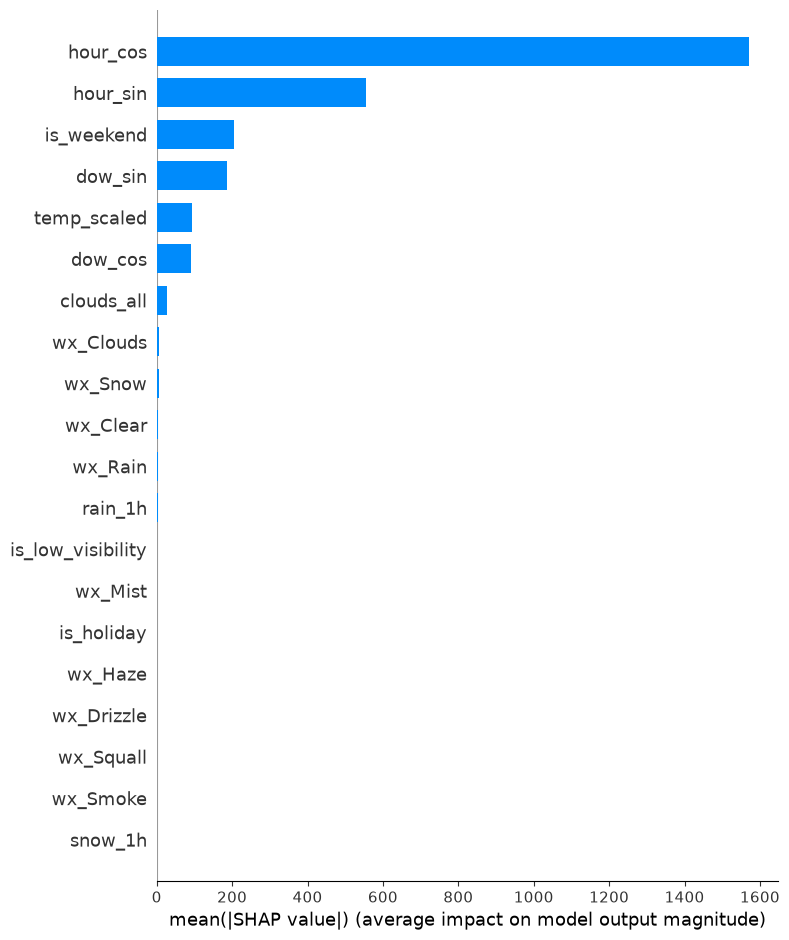

In [36]:
import shap

explainer = shap.TreeExplainer(rf_reg_loaded)
shap_values = explainer.shap_values(X_test_tab)

print(f"shap_values shape: {shap_values.shape}")

shap.summary_plot(shap_values, X_test_tab, plot_type="bar", show=True)

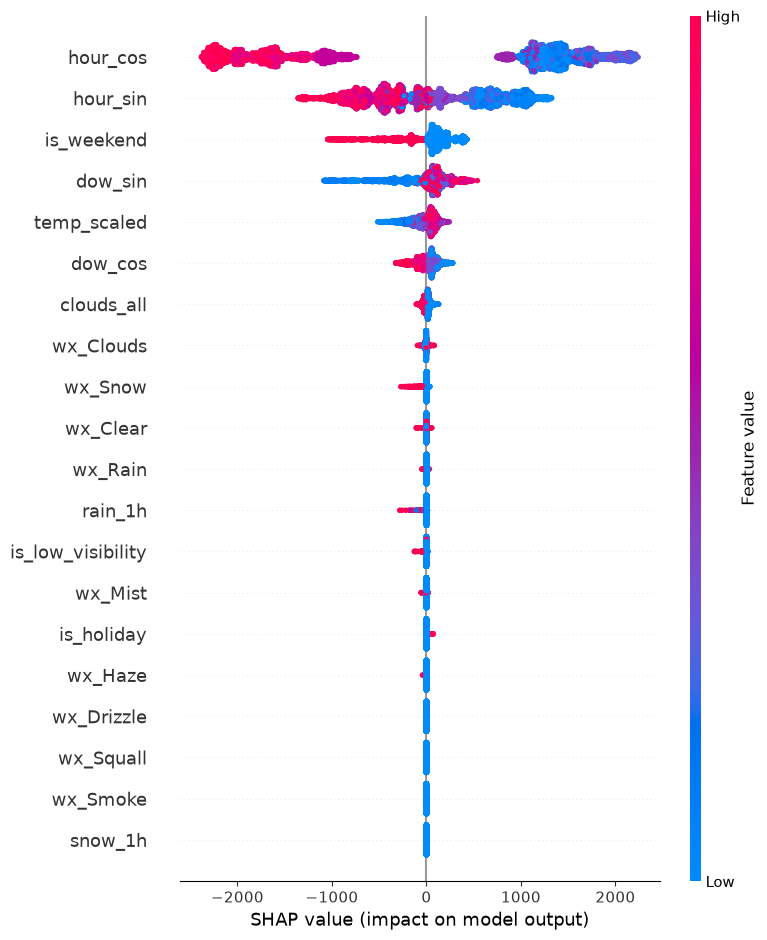

In [37]:
shap.summary_plot(shap_values, X_test_tab, show=True)

### Step 9 (continued): Resolve the hour_sin/hour_cos ambiguity

hour_cos and hour_sin encode hour as a point on a circle, so a single cosine or sine value doesn't map to one specific time of day, the same value can occur at two very different hours. Reading direction and color directly off the beeswarm's hour_cos row risks stating something backwards. Summing both features' SHAP contributions and grouping by the actual `hour` column instead gives an unambiguous, directly interpretable answer.

In [38]:
hour_sin_idx = FEATURE_COLS.index("hour_sin")
hour_cos_idx = FEATURE_COLS.index("hour_cos")

time_shap_contribution = shap_values[:, hour_sin_idx] + shap_values[:, hour_cos_idx]

hour_effect = pd.DataFrame({
    "hour": test_df_tab["hour"].values,
    "time_shap_contribution": time_shap_contribution,
}).groupby("hour")["time_shap_contribution"].mean()

print(hour_effect.round(1))

hour
0    -2424.0
1    -2749.4
2    -2878.5
3    -2898.0
4    -2574.3
5    -1188.2
6      875.3
7     1487.6
8     1338.9
9     1086.0
10     920.4
11    1212.1
12    1444.7
13    1450.2
14    1669.4
15    1973.2
16    2362.9
17    2076.7
18    1018.0
19      12.5
20    -428.7
21    -574.0
22   -1046.9
23   -1802.1
Name: time_shap_contribution, dtype: float64


## Task 4 — Advanced AI Technique: MLflow for Experiment Tracking

MLflow is applied retrospectively across every model built in Tasks 1-3, wrapping each one in a tracked run (hyperparameters, metrics recomputed fresh from the saved model, and the model file itself as an artifact). This gives one place to compare every model side by side and lays the groundwork for Task 6's MLOps component, which the brief explicitly asks to use MLflow tracking again.

In [40]:
import mlflow

MLFLOW_DIR = PART3_DIR / "mlflow"
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DIR.as_posix()}/mlflow.db")
mlflow.set_experiment("smart_city_traffic_capstone")

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {mlflow.get_experiment_by_name('smart_city_traffic_capstone')}")

2026/09/13 20:24:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/13 20:24:45 INFO mlflow.store.db.utils: Updating database tables
2026/09/13 20:24:48 INFO mlflow.tracking.fluent: Experiment with name 'smart_city_traffic_capstone' does not exist. Creating a new experiment.


Tracking URI: sqlite:///C:/Users/user/OneDrive/Documents/AI ML and DS Course NUS/Capstone Project/smart-city-traffic-capstone/part3_machine_learning/mlflow/mlflow.db
Experiment: <Experiment: artifact_location=('file:C:/Users/user/OneDrive/Documents/AI ML and DS Course NUS/Capstone '
 'Project/smart-city-traffic-capstone/part3_machine_learning/notebooks/mlruns/1'), creation_time=1789302288675, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789302288675, lifecycle_stage='active', name='smart_city_traffic_capstone', tags={}, trace_location=None, workspace='default'>


In [42]:
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DIR.as_posix()}/tracking.db")

ARTIFACT_DIR = MLFLOW_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

experiment = mlflow.get_experiment_by_name("smart_city_traffic_capstone")
if experiment is None:
    mlflow.create_experiment("smart_city_traffic_capstone", artifact_location=ARTIFACT_DIR.as_uri())

mlflow.set_experiment("smart_city_traffic_capstone")

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {mlflow.get_experiment_by_name('smart_city_traffic_capstone')}")

2026/09/13 20:30:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/13 20:30:14 INFO mlflow.store.db.utils: Updating database tables


Tracking URI: sqlite:///C:/Users/user/OneDrive/Documents/AI ML and DS Course NUS/Capstone Project/smart-city-traffic-capstone/part3_machine_learning/mlflow/tracking.db
Experiment: <Experiment: artifact_location='file:///C:/Users/user/OneDrive/Documents/AI%20ML%20and%20DS%20Course%20NUS/Capstone%20Project/smart-city-traffic-capstone/part3_machine_learning/mlflow/artifacts', creation_time=1789302616865, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789302616865, lifecycle_stage='active', name='smart_city_traffic_capstone', tags={}, trace_location=None, workspace='default'>


### Step 2: Log Task 1's four models

Each model is reloaded from disk, its exact test set rebuilt via the same functions used to train it (`chronological_split`, `build_feature_targets` from `supervised_models.py`), and its metrics recomputed fresh rather than copied from earlier output, this guarantees what's logged to MLflow always matches the actual saved model, not a possibly-stale number. Hyperparameters come directly from each model's own `get_params()`, so nothing needs retyping by hand.

In [43]:
import joblib
from supervised_models import FEATURE_COLS, chronological_split, build_feature_targets
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, r2_score,
)

task1_ml_df = prepare_data()
task1_train_df, task1_test_df = chronological_split(task1_ml_df)
X_train_t1, X_test_t1, y_train_clf_t1, y_test_clf_t1, y_train_reg_t1, y_test_reg_t1 = build_feature_targets(
    task1_train_df, task1_test_df
)

SUP_MODELS_DIR = PART3_DIR / "models"

clf_specs = [
    ("logistic_regression_high_risk.joblib", "Logistic Regression (high_risk)"),
    ("random_forest_high_risk.joblib", "Random Forest (high_risk)"),
]

for filename, run_name in clf_specs:
    model = joblib.load(SUP_MODELS_DIR / filename)
    y_pred = model.predict(X_test_t1)
    y_proba = model.predict_proba(X_test_t1)[:, 1]

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(model.get_params())
        mlflow.log_metric("accuracy", accuracy_score(y_test_clf_t1, y_pred))
        mlflow.log_metric("precision", precision_score(y_test_clf_t1, y_pred))
        mlflow.log_metric("recall", recall_score(y_test_clf_t1, y_pred))
        mlflow.log_metric("f1", f1_score(y_test_clf_t1, y_pred))
        mlflow.log_metric("roc_auc", roc_auc_score(y_test_clf_t1, y_proba))
        mlflow.log_artifact(str(SUP_MODELS_DIR / filename))
    print(f"Logged: {run_name}")

reg_specs = [
    ("linear_regression_traffic_volume.joblib", "Linear Regression (traffic_volume)"),
    ("random_forest_traffic_volume.joblib", "Random Forest (traffic_volume)"),
]

for filename, run_name in reg_specs:
    model = joblib.load(SUP_MODELS_DIR / filename)
    y_pred = model.predict(X_test_t1)

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(model.get_params())
        mlflow.log_metric("mae", mean_absolute_error(y_test_reg_t1, y_pred))
        mlflow.log_metric("r2", r2_score(y_test_reg_t1, y_pred))
        mlflow.log_artifact(str(SUP_MODELS_DIR / filename))
    print(f"Logged: {run_name}")

Standardised casing to lowercase in 1730 rows of 'weather_description' (merging case-variant duplicates such as 'Sky is Clear' / 'sky is clear').
Removed 17 exact duplicate rows.
Collapsed 5430 duplicate-timestamp hours (7612 rows removed) down to one row per hour; 0 of these hours had inconsistent traffic_volume across duplicates.
Found 10 rows with physically impossible 'temp' readings (<= 0 Kelvin).
Found 1 rows with physically implausible 'rain_1h' readings (> 1000mm/hour): [9831.3]
Imputed 4 missing 'temp' value(s) in month 1 using that month's median (265.48).
Imputed 6 missing 'temp' value(s) in month 2 using that month's median (265.89).
Imputed 1 missing 'rain_1h' value(s) in month 7 using that month's median (0.00).


Logged: Logistic Regression (high_risk)
Logged: Random Forest (high_risk)
Logged: Linear Regression (traffic_volume)
Logged: Random Forest (traffic_volume)


### Step 3: Log Task 2's K-means clustering and association rule mining

K-means gets one run (model + scaler reloaded, inertia and silhouette recomputed fresh, matching what Step 3 of Task 2 already found). Association rule mining gets a second run, re-mined fresh via the same functions from `unsupervised_models.py` (cheap, no retraining concept applies here), logging the mining parameters and the resulting rule counts.

In [44]:
from sklearn.metrics import silhouette_score
from unsupervised_models import (
    add_weather_severity, CLUSTER_FEATURES, discretize_for_arm, mine_congestion_rules, MIN_SUPPORT,
)

UNSUP_MODELS_DIR = PART3_DIR / "models"

# --- K-means ---
kmeans_model = joblib.load(UNSUP_MODELS_DIR / "kmeans_traffic_clusters.joblib")
kmeans_scaler = joblib.load(UNSUP_MODELS_DIR / "kmeans_scaler.joblib")

task2_ml_df = add_weather_severity(prepare_data())
X_cluster_t2 = kmeans_scaler.transform(task2_ml_df[CLUSTER_FEATURES])
cluster_labels = kmeans_model.predict(X_cluster_t2)
sil_score = silhouette_score(X_cluster_t2, cluster_labels, sample_size=5000, random_state=42)

with mlflow.start_run(run_name="K-means Clustering (k=6)"):
    mlflow.log_params(kmeans_model.get_params())
    mlflow.log_metric("inertia", kmeans_model.inertia_)
    mlflow.log_metric("silhouette", sil_score)
    mlflow.log_artifact(str(UNSUP_MODELS_DIR / "kmeans_traffic_clusters.joblib"))
    mlflow.log_artifact(str(UNSUP_MODELS_DIR / "kmeans_scaler.joblib"))
    mlflow.log_artifact(str(PART3_DIR / "task2_cluster_profile.csv"))
print("Logged: K-means Clustering (k=6)")

# --- Association rule mining ---
arm_df_t2 = discretize_for_arm(task2_ml_df)
congestion_rules_t2 = mine_congestion_rules(arm_df_t2)

with mlflow.start_run(run_name="Association Rule Mining (Apriori)"):
    mlflow.log_param("min_support", MIN_SUPPORT)
    mlflow.log_metric("n_congestion_rules", len(congestion_rules_t2))
    mlflow.log_metric("max_lift", congestion_rules_t2["lift"].max())
    mlflow.log_artifact(str(PART3_DIR / "task2_congestion_rules.csv"))
print("Logged: Association Rule Mining (Apriori)")

Standardised casing to lowercase in 1730 rows of 'weather_description' (merging case-variant duplicates such as 'Sky is Clear' / 'sky is clear').
Removed 17 exact duplicate rows.
Collapsed 5430 duplicate-timestamp hours (7612 rows removed) down to one row per hour; 0 of these hours had inconsistent traffic_volume across duplicates.
Found 10 rows with physically impossible 'temp' readings (<= 0 Kelvin).
Found 1 rows with physically implausible 'rain_1h' readings (> 1000mm/hour): [9831.3]
Imputed 4 missing 'temp' value(s) in month 1 using that month's median (265.48).
Imputed 6 missing 'temp' value(s) in month 2 using that month's median (265.89).
Imputed 1 missing 'rain_1h' value(s) in month 7 using that month's median (0.00).


Logged: K-means Clustering (k=6)
Logged: Association Rule Mining (Apriori)


### Step 4: Log Task 3's LSTM (and its SHAP explainability artifacts)

Keras doesn't expose `get_params()` the way scikit-learn models do, so its architecture hyperparameters are logged explicitly instead. The two SHAP plots are attached to this run too, since they were produced as part of Task 3's explainability work (applied to the comparable random forest per the documented substitution), even though the LSTM itself isn't what SHAP explained.

In [45]:
from tensorflow.keras.models import load_model
from deep_learning_explainability import (
    build_gap_aware_windows, chronological_split_windows, scale_sequences, LOOKBACK, SEQ_FEATURES,
)

DL_MODELS_DIR = PART3_DIR / "models"

lstm_model_loaded = load_model(DL_MODELS_DIR / "lstm_traffic_volume.keras")
lstm_scaler_volume = joblib.load(DL_MODELS_DIR / "lstm_scaler_volume.joblib")
lstm_scaler_severity = joblib.load(DL_MODELS_DIR / "lstm_scaler_severity.joblib")

task3_ml_df = prepare_data()
task3_ml_df["weather_severity"] = task3_ml_df["weather_main"].map(WEATHER_SEVERITY_RANK)

gap_df_t3, X_raw_t3, y_raw_t3, target_dates_t3 = build_gap_aware_windows(task3_ml_df)
_, X_test_raw_t3, _, y_test_raw_t3, cutoff_date_t3 = chronological_split_windows(
    gap_df_t3, X_raw_t3, y_raw_t3, target_dates_t3
)

X_test_t3, y_test_t3 = scale_sequences(X_test_raw_t3, y_test_raw_t3, lstm_scaler_volume, lstm_scaler_severity)

y_pred_scaled_t3 = lstm_model_loaded.predict(X_test_t3, verbose=0).flatten()
y_pred_t3 = lstm_scaler_volume.inverse_transform(y_pred_scaled_t3.reshape(-1, 1)).flatten()
y_true_t3 = lstm_scaler_volume.inverse_transform(y_test_t3.reshape(-1, 1)).flatten()

lstm_mae_mlflow = mean_absolute_error(y_true_t3, y_pred_t3)
lstm_r2_mlflow = r2_score(y_true_t3, y_pred_t3)

with mlflow.start_run(run_name="LSTM (traffic_volume, 24h lookback)"):
    mlflow.log_params({
        "lookback_hours": LOOKBACK,
        "lstm_units": 64,
        "dropout": 0.2,
        "dense_units": 32,
        "batch_size": 64,
        "max_epochs": 30,
        "early_stopping_patience": 5,
        "features": ",".join(SEQ_FEATURES),
    })
    mlflow.log_metric("mae", lstm_mae_mlflow)
    mlflow.log_metric("r2", lstm_r2_mlflow)
    mlflow.log_artifact(str(DL_MODELS_DIR / "lstm_traffic_volume.keras"))
    mlflow.log_artifact(str(DL_MODELS_DIR / "lstm_scaler_volume.joblib"))
    mlflow.log_artifact(str(DL_MODELS_DIR / "lstm_scaler_severity.joblib"))
    mlflow.log_artifact(str(PART3_DIR / "figures" / "shap_bar_traffic_volume.png"))
    mlflow.log_artifact(str(PART3_DIR / "figures" / "shap_beeswarm_traffic_volume.png"))

print(f"Logged: LSTM (traffic_volume, 24h lookback) — MAE={lstm_mae_mlflow:.2f}, R2={lstm_r2_mlflow:.4f}")

Standardised casing to lowercase in 1730 rows of 'weather_description' (merging case-variant duplicates such as 'Sky is Clear' / 'sky is clear').
Removed 17 exact duplicate rows.
Collapsed 5430 duplicate-timestamp hours (7612 rows removed) down to one row per hour; 0 of these hours had inconsistent traffic_volume across duplicates.
Found 10 rows with physically impossible 'temp' readings (<= 0 Kelvin).
Found 1 rows with physically implausible 'rain_1h' readings (> 1000mm/hour): [9831.3]
Imputed 4 missing 'temp' value(s) in month 1 using that month's median (265.48).
Imputed 6 missing 'temp' value(s) in month 2 using that month's median (265.89).
Imputed 1 missing 'rain_1h' value(s) in month 7 using that month's median (0.00).


Logged: LSTM (traffic_volume, 24h lookback) — MAE=191.17, R2=0.9821


### Step 5: Pull a consolidated comparison table across all runs

`mlflow.search_runs()` returns every logged run as a DataFrame, giving one place to see every model's key metric side by side, exactly the value MLflow is meant to add. This table is also worth a screenshot for the report.

In [46]:
runs_df = mlflow.search_runs(order_by=["start_time"])
summary_cols = [c for c in runs_df.columns if c.startswith("tags.mlflow.runName") or c.startswith("metrics.")]
print(runs_df[summary_cols].to_string(index=False))

 metrics.roc_auc  metrics.precision  metrics.recall  metrics.f1  metrics.accuracy  metrics.r2  metrics.mae  metrics.inertia  metrics.silhouette  metrics.max_lift  metrics.n_congestion_rules                 tags.mlflow.runName
        0.997794           0.713584             1.0    0.832856          0.978435         NaN          NaN              NaN                 NaN               NaN                         NaN     Logistic Regression (high_risk)
        0.998832           0.830476             1.0    0.907388          0.989033         NaN          NaN              NaN                 NaN               NaN                         NaN           Random Forest (high_risk)
             NaN                NaN             NaN         NaN               NaN    0.708932   828.249294              NaN                 NaN               NaN                         NaN  Linear Regression (traffic_volume)
             NaN                NaN             NaN         NaN               NaN    0.941054   

### Task 5 Setup: Reloading State for a Fresh Kernel Session

The cells below rebuild `ml_df` and reload the random forest regressor that were already built, trained, and evaluated in Task 1. No new data preparation or model training happens here; this is a kernel restart, not a repeated analysis step. `prepare_data()` deterministically reproduces the same cleaned, feature engineered dataset from Part 2's pipeline, and `random_forest_traffic_volume.joblib` is the exact saved model artifact committed to the repository. This setup is required because Task 5 builds directly on Task 1's trained regressor to simulate expected traffic volume under different scenarios.

In [1]:
import sys
from pathlib import Path

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PART3_DIR = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PART3_DIR))

from data_prep import prepare_data

ml_df = prepare_data()
ml_df = ml_df.sort_values("date_time").reset_index(drop=True)

split_idx = int(len(ml_df) * 0.8)
cutoff_date = ml_df.loc[split_idx, "date_time"]

train_df = ml_df[ml_df["date_time"] < cutoff_date].copy()
test_df = ml_df[ml_df["date_time"] >= cutoff_date].copy()

print(f"Cutoff date: {cutoff_date}")
print(f"Train: {train_df.shape[0]} rows  ({train_df['date_time'].min()} to {train_df['date_time'].max()})")
print(f"Test:  {test_df.shape[0]} rows  ({test_df['date_time'].min()} to {test_df['date_time'].max()})")

Standardised casing to lowercase in 1730 rows of 'weather_description' (merging case-variant duplicates such as 'Sky is Clear' / 'sky is clear').
Removed 17 exact duplicate rows.
Collapsed 5430 duplicate-timestamp hours (7612 rows removed) down to one row per hour; 0 of these hours had inconsistent traffic_volume across duplicates.
Found 10 rows with physically impossible 'temp' readings (<= 0 Kelvin).
Found 1 rows with physically implausible 'rain_1h' readings (> 1000mm/hour): [9831.3]
Imputed 4 missing 'temp' value(s) in month 1 using that month's median (265.48).
Imputed 6 missing 'temp' value(s) in month 2 using that month's median (265.89).
Imputed 1 missing 'rain_1h' value(s) in month 7 using that month's median (0.00).


Cutoff date: 2017-10-26 18:00:00
Train: 32460 rows  (2012-10-02 09:00:00 to 2017-10-26 17:00:00)
Test:  8115 rows  (2017-10-26 18:00:00 to 2018-09-30 23:00:00)


In [2]:
import joblib

FEATURE_COLS = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_holiday",
    "wx_Clear", "wx_Clouds", "wx_Drizzle", "wx_Fog", "wx_Haze", "wx_Mist",
    "wx_Rain", "wx_Smoke", "wx_Snow", "wx_Squall", "wx_Thunderstorm",
    "is_severe_weather", "is_low_visibility",
    "temp_scaled", "rain_1h", "snow_1h", "clouds_all",
]

MODELS_DIR = PART3_DIR / "models"
rf_regressor = joblib.load(MODELS_DIR / "random_forest_traffic_volume.joblib")

print("Loaded random_forest_traffic_volume.joblib")
print("n_features_in_:", rf_regressor.n_features_in_, "| expected:", len(FEATURE_COLS))

Loaded random_forest_traffic_volume.joblib
n_features_in_: 23 | expected: 23


## Task 5: Traffic Recommendation System

**Objective.** Turn the trained models and historical patterns from Tasks 1 to 3 into a practical, plain language travel timing recommender. Since this dataset covers a single corridor rather than a road network, the system recommends when to travel rather than which route to take.

**Approach.**
1. Reuse the Task 1 random forest regressor to simulate expected traffic volume across all 24 hours of the day, for a given day type (weekday or weekend) and, optionally, a weather condition. This is done by holding every other feature at a representative value and varying only the hour and its cyclical encoding, so the system predicts rather than merely looks up historical averages.
2. Where a weather condition is not specified, aggregate predictions across all observed weather categories, weighted by how often each occurs historically, to give a realistic "typical day" recommendation.
3. Cross check the model's ranking against simple historical group averages computed directly from `ml_df`, as a transparent, non model baseline.
4. Identify the lowest traffic contiguous window from the ranked hours and generate a plain language recommendation sentence.

**Limitation to note upfront:** this system recommends timing only, not routes, a direct consequence of the dataset covering a single Minneapolis or St Paul I94 corridor with no alternate route data, as flagged in the brief itself.

### Step 1: Build representative conditions for each weather category

In [3]:
WEATHER_CATEGORIES = ["Clear", "Clouds", "Drizzle", "Fog", "Haze", "Mist",
                       "Rain", "Smoke", "Snow", "Squall", "Thunderstorm"]

weather_frequency = {cat: ml_df[f"wx_{cat}"].mean() for cat in WEATHER_CATEGORIES}

weather_profile = (
    ml_df.groupby("weather_main")[["temp_scaled", "rain_1h", "snow_1h", "clouds_all"]]
    .mean()
)

print("Historical frequency of each weather category:")
for cat, freq in sorted(weather_frequency.items(), key=lambda x: -x[1]):
    print(f"  {cat:14s} {freq:.4f}")

print("\nRepresentative continuous conditions per category:")
print(weather_profile.round(3))

Historical frequency of each weather category:
  Clouds         0.3727
  Clear          0.3294
  Rain           0.1175
  Mist           0.0756
  Snow           0.0566
  Haze           0.0189
  Drizzle        0.0127
  Thunderstorm   0.0112
  Fog            0.0050
  Smoke          0.0004
  Squall         0.0000

Representative continuous conditions per category:
              temp_scaled  rain_1h  snow_1h  clouds_all
weather_main                                           
Clear               0.024    0.000    0.000       1.548
Clouds              0.006    0.000    0.000      64.070
Drizzle             0.069    0.000    0.000      80.483
Fog                 0.035    0.000    0.000      41.224
Haze               -0.261    0.000    0.000      51.106
Mist               -0.157    0.000    0.000      52.957
Rain                0.471    0.649    0.000      70.703
Smoke               0.679    0.000    0.000      48.933
Snow               -1.072    0.000    0.002      81.172
Squall              0

### Step 2: Simulate expected traffic volume by hour, day type, and weather

In [7]:
import numpy as np
import pandas as pd
from data_prep import SEVERE_WEATHER, LOW_VISIBILITY_CONDITIONS

def build_simulation_rows(day_type, weather_condition=None):
    if day_type == "weekday":
        is_weekend, representative_dow = 0, 2   # Wednesday: typical midweek day
    elif day_type == "weekend":
        is_weekend, representative_dow = 1, 5   # Saturday: typical weekend day
    else:
        raise ValueError("day_type must be 'weekday' or 'weekend'")

    dow_sin = np.sin(2 * np.pi * representative_dow / 7)
    dow_cos = np.cos(2 * np.pi * representative_dow / 7)
    categories = [weather_condition] if weather_condition else WEATHER_CATEGORIES

    rows = []
    for cat in categories:
        conditions = weather_profile.loc[cat]
        for hour in range(24):
            row = {col: 0 for col in FEATURE_COLS}
            row["hour_sin"] = np.sin(2 * np.pi * hour / 24)
            row["hour_cos"] = np.cos(2 * np.pi * hour / 24)
            row["dow_sin"] = dow_sin
            row["dow_cos"] = dow_cos
            row["is_weekend"] = is_weekend
            row["is_holiday"] = 0
            row[f"wx_{cat}"] = 1
            row["is_severe_weather"] = int(cat in SEVERE_WEATHER)
            row["is_low_visibility"] = int(cat in LOW_VISIBILITY_CONDITIONS)
            row["temp_scaled"] = conditions["temp_scaled"]
            row["rain_1h"] = conditions["rain_1h"]
            row["snow_1h"] = conditions["snow_1h"]
            row["clouds_all"] = conditions["clouds_all"]
            rows.append({"category": cat, "hour": hour, **row})
    return pd.DataFrame(rows)


def simulate_hourly_profile(day_type, weather_condition=None):
    sim_rows = build_simulation_rows(day_type, weather_condition)
    sim_rows["predicted_volume"] = rf_regressor.predict(sim_rows[FEATURE_COLS])

    if weather_condition:
        return sim_rows.set_index("hour")["predicted_volume"]

    # No specific weather: weight each category's prediction by historical frequency
    sim_rows["weight"] = sim_rows["category"].map(weather_frequency)
    sim_rows["weighted_pred"] = sim_rows["predicted_volume"] * sim_rows["weight"]
    return sim_rows.groupby("hour")["weighted_pred"].sum()


# Verify on one example: an average weekday, weather not specified
example_profile = simulate_hourly_profile("weekday")
print(example_profile.round(1))

hour
0      586.5
1      381.4
2      295.1
3      370.9
4      866.9
5     2897.3
6     5759.8
7     6422.5
8     5867.6
9     5231.8
10    4511.0
11    4776.8
12    4941.5
13    4946.7
14    5236.1
15    5758.5
16    6452.6
17    6163.6
18    4564.5
19    3320.7
20    2845.0
21    2573.9
22    1831.9
23    1169.5
Name: weighted_pred, dtype: float64


### Step 3: Cross check the simulated profile against historical averages

In [8]:
historical_weekday_profile = (
    ml_df[ml_df["is_weekend"] == 0]
    .groupby("hour")["traffic_volume"]
    .mean()
)

comparison = pd.DataFrame({
    "simulated": example_profile,
    "historical_mean": historical_weekday_profile,
})
comparison["difference"] = comparison["simulated"] - comparison["historical_mean"]

print(comparison.round(1))
print(f"\nCorrelation between simulated and historical: {comparison['simulated'].corr(comparison['historical_mean']):.4f}")

      simulated  historical_mean  difference
hour                                        
0         586.5            655.2       -68.7
1         381.4            400.2       -18.8
2         295.1            303.1        -8.0
3         370.9            362.9         8.1
4         866.9            830.1        36.7
5        2897.3           2699.3       198.0
6        5759.8           5375.3       384.5
7        6422.5           6061.2       361.4
8        5867.6           5508.9       358.7
9        5231.8           4900.6       331.2
10       4511.0           4400.5       110.5
11       4776.8           4663.4       113.4
12       4941.5           4873.9        67.6
13       4946.7           4879.5        67.2
14       5236.1           5182.1        54.0
15       5758.5           5629.2       129.3
16       6452.6           6240.9       211.7
17       6163.6           5822.9       340.7
18       4564.5           4485.0        79.5
19       3320.7           3332.1       -11.4
20       2

### Interpreting the correlation between simulated and historical profiles

The near-perfect correlation (0.9981) between the model's simulated hourly profile and the raw historical hourly mean is expected rather than surprising, given the dominant role of hour of day already established across Tasks 1 through 3 (feature importance, clustering, association rules, and SHAP all converge on this finding). Both curves are aggregated hourly averages that isolate the same primary signal, and the historical baseline used here draws on the full dataset rather than a held-out split, since the intent is to check internal consistency of the recommendation engine rather than to re-validate generalization already tested in Task 1. The small but systematic residual (simulated values running 5 to 8 percent above historical during daytime hours and below overnight) reflects the simplification of holding day of week and weather at single representative values rather than conditioning them jointly on hour, a documented limitation of the scenario simulation approach.

### Step 4: Select the recommended travel window and generate the plain-language output

In [9]:
def find_best_window(hourly_profile, window_size=1, earliest_hour=5, latest_hour=22):
    """Find the contiguous window of `window_size` hours, within [earliest_hour, latest_hour],
    with the lowest average predicted traffic volume.

    The search is restricted to a realistic travel range (5 AM to 10 PM by default) rather
    than the full 24 hours, since the mathematical global minimum falls in the overnight hours
    (around 2 to 3 AM), which is not a practical commuting recommendation. This is a deliberate
    design choice, not a limitation of the underlying model.
    """
    best_start, best_avg = None, np.inf
    last_valid_start = latest_hour - window_size + 1
    for start in range(earliest_hour, last_valid_start + 1):
        window_avg = hourly_profile.loc[start:start + window_size - 1].mean()
        if window_avg < best_avg:
            best_avg = window_avg
            best_start = start
    return best_start, best_start + window_size, best_avg


def format_hour(h):
    h = h % 24
    period = "AM" if h < 12 else "PM"
    display = h % 12
    display = 12 if display == 0 else display
    return f"{display}:00 {period}"


def generate_recommendation(day_type, weather_condition=None, window_size=1,
                             earliest_hour=5, latest_hour=22):
    profile = simulate_hourly_profile(day_type, weather_condition)
    start, end, avg_volume = find_best_window(profile, window_size, earliest_hour, latest_hour)
    peak_volume = profile.max()
    pct_lower = (1 - avg_volume / peak_volume) * 100

    day_phrase = "weekday" if day_type == "weekday" else "weekend"
    weather_phrase = f" during {weather_condition.lower()} conditions" if weather_condition else ""

    message = (
        f"For a {day_phrase} journey{weather_phrase}, consider travelling between "
        f"{format_hour(start)} and {format_hour(end)}, when historical traffic volumes are "
        f"typically lower (predicted volume approximately {avg_volume:.0f}, "
        f"{pct_lower:.0f}% below the daily peak of approximately {peak_volume:.0f})."
    )
    return message


# Demonstrate across a few representative scenarios
scenarios = [
    ("weekday", None),
    ("weekend", None),
    ("weekday", "Snow"),
    ("weekday", "Thunderstorm"),
]

for day_type, weather in scenarios:
    print(generate_recommendation(day_type, weather))
    print()

For a weekday journey, consider travelling between 10:00 PM and 11:00 PM, when historical traffic volumes are typically lower (predicted volume approximately 1832, 72% below the daily peak of approximately 6453).

For a weekend journey, consider travelling between 5:00 AM and 6:00 AM, when historical traffic volumes are typically lower (predicted volume approximately 801, 83% below the daily peak of approximately 4729).

For a weekday journey during snow conditions, consider travelling between 10:00 PM and 11:00 PM, when historical traffic volumes are typically lower (predicted volume approximately 1808, 69% below the daily peak of approximately 5825).

For a weekday journey during thunderstorm conditions, consider travelling between 10:00 PM and 11:00 PM, when historical traffic volumes are typically lower (predicted volume approximately 2017, 69% below the daily peak of approximately 6508).



### Step 4 (revised): Distinguish genuine off-peak troughs from search-boundary artifacts

In [10]:
def find_local_minima(hourly_profile):
    """Hours that are local minima on the full 24-hour circular profile: lower than or
    equal to both immediate neighbours, wrapping midnight to midnight. This distinguishes
    a genuine trough (traffic falls, then rises again) from a point that only looks lowest
    because a search range was cut off there."""
    minima = []
    for h in range(24):
        prev_h, next_h = (h - 1) % 24, (h + 1) % 24
        if hourly_profile[h] <= hourly_profile[prev_h] and hourly_profile[h] <= hourly_profile[next_h]:
            minima.append(h)
    return minima


def find_best_window(hourly_profile, window_size=1, earliest_hour=5, latest_hour=22):
    reasonable_hours = set(range(earliest_hour, latest_hour + 1))
    local_minima = [h for h in find_local_minima(hourly_profile) if h in reasonable_hours]

    if local_minima:
        best_hour = min(local_minima, key=lambda h: hourly_profile[h])
        is_trough = True
    else:
        best_hour = hourly_profile.loc[earliest_hour:latest_hour].idxmin()
        is_trough = False

    half = (window_size - 1) // 2
    start = max(earliest_hour, best_hour - half)
    end = min(latest_hour + 1, start + window_size)
    start = end - window_size
    avg_volume = hourly_profile.loc[start:end - 1].mean()
    return start, end, avg_volume, is_trough


def generate_recommendation(day_type, weather_condition=None, window_size=1,
                             earliest_hour=5, latest_hour=22):
    profile = simulate_hourly_profile(day_type, weather_condition)
    start, end, avg_volume, is_trough = find_best_window(profile, window_size, earliest_hour, latest_hour)
    peak_volume = profile.max()
    pct_lower = (1 - avg_volume / peak_volume) * 100

    day_phrase = "weekday" if day_type == "weekday" else "weekend"
    weather_phrase = f" during {weather_condition.lower()} conditions" if weather_condition else ""

    if is_trough:
        message = (
            f"For a {day_phrase} journey{weather_phrase}, consider travelling between "
            f"{format_hour(start)} and {format_hour(end)}, when historical traffic volumes dip to a "
            f"local low between busier periods (predicted volume approximately {avg_volume:.0f}, "
            f"{pct_lower:.0f}% below the daily peak of approximately {peak_volume:.0f})."
        )
    else:
        message = (
            f"For a {day_phrase} journey{weather_phrase}, traffic volumes rise fairly steadily through "
            f"the day with no clear midday dip; the lowest point within typical travel hours is around "
            f"{format_hour(start)} to {format_hour(end)} (predicted volume approximately {avg_volume:.0f}, "
            f"{pct_lower:.0f}% below the daily peak of approximately {peak_volume:.0f})."
        )
    return message


scenarios = [
    ("weekday", None),
    ("weekend", None),
    ("weekday", "Snow"),
    ("weekday", "Thunderstorm"),
]

for day_type, weather in scenarios:
    print(generate_recommendation(day_type, weather))
    print()

For a weekday journey, consider travelling between 10:00 AM and 11:00 AM, when historical traffic volumes dip to a local low between busier periods (predicted volume approximately 4511, 30% below the daily peak of approximately 6453).

For a weekend journey, consider travelling between 8:00 PM and 9:00 PM, when historical traffic volumes dip to a local low between busier periods (predicted volume approximately 3026, 36% below the daily peak of approximately 4729).

For a weekday journey during snow conditions, consider travelling between 10:00 AM and 11:00 AM, when historical traffic volumes dip to a local low between busier periods (predicted volume approximately 4334, 26% below the daily peak of approximately 5825).

For a weekday journey during thunderstorm conditions, consider travelling between 10:00 AM and 11:00 AM, when historical traffic volumes dip to a local low between busier periods (predicted volume approximately 4589, 29% below the daily peak of approximately 6508).



### Step 4 (diagnostic): Inspect the full weekend hourly profile

In [11]:
weekend_profile = simulate_hourly_profile("weekend")
print(weekend_profile.round(1))

hour
0     1289.6
1      779.5
2      594.5
3      390.1
4      446.5
5      800.9
6     1417.8
7     2123.0
8     3060.7
9     3726.6
10    3982.4
11    4341.5
12    4728.5
13    4625.7
14    4615.9
15    4595.0
16    4595.0
17    4526.3
18    4193.1
19    3443.4
20    3026.4
21    3067.3
22    3123.1
23    2376.5
Name: weighted_pred, dtype: float64


### Step 4 (further revised): Require meaningful prominence, not just any dip

In [12]:
def find_local_minima(hourly_profile, min_prominence_pct=5.0):
    """Hours that are local minima on the full 24-hour circular profile, with a
    minimum prominence requirement: the dip must be at least `min_prominence_pct`
    percent below the SMALLER of its two neighbouring rises. This filters out
    single-hour noise wiggles (e.g. a 1% dip from tree-split artifacts) and keeps
    only genuine troughs where traffic meaningfully falls and then rises again."""
    minima = []
    n = 24
    for h in range(n):
        prev_h, next_h = (h - 1) % n, (h + 1) % n
        val, prev_val, next_val = hourly_profile[h], hourly_profile[prev_h], hourly_profile[next_h]
        if val <= prev_val and val <= next_val:
            prominence = min(prev_val - val, next_val - val)
            if val > 0 and (prominence / val) * 100 >= min_prominence_pct:
                minima.append(h)
    return minima


def find_best_window(hourly_profile, window_size=1, earliest_hour=7, latest_hour=22,
                      min_prominence_pct=5.0):
    reasonable_hours = set(range(earliest_hour, latest_hour + 1))
    local_minima = [h for h in find_local_minima(hourly_profile, min_prominence_pct) if h in reasonable_hours]

    if local_minima:
        best_hour = min(local_minima, key=lambda h: hourly_profile[h])
        is_trough = True
    else:
        best_hour = hourly_profile.loc[earliest_hour:latest_hour].idxmin()
        is_trough = False

    half = (window_size - 1) // 2
    start = max(earliest_hour, best_hour - half)
    end = min(latest_hour + 1, start + window_size)
    start = end - window_size
    avg_volume = hourly_profile.loc[start:end - 1].mean()
    return start, end, avg_volume, is_trough


def generate_recommendation(day_type, weather_condition=None, window_size=1,
                             earliest_hour=7, latest_hour=22, min_prominence_pct=5.0):
    profile = simulate_hourly_profile(day_type, weather_condition)
    start, end, avg_volume, is_trough = find_best_window(
        profile, window_size, earliest_hour, latest_hour, min_prominence_pct
    )
    peak_volume = profile.max()
    pct_lower = (1 - avg_volume / peak_volume) * 100

    day_phrase = "weekday" if day_type == "weekday" else "weekend"
    weather_phrase = f" during {weather_condition.lower()} conditions" if weather_condition else ""

    if is_trough:
        message = (
            f"For a {day_phrase} journey{weather_phrase}, consider travelling between "
            f"{format_hour(start)} and {format_hour(end)}, when historical traffic volumes dip to a "
            f"local low between busier periods (predicted volume approximately {avg_volume:.0f}, "
            f"{pct_lower:.0f}% below the daily peak of approximately {peak_volume:.0f})."
        )
    else:
        message = (
            f"For a {day_phrase} journey{weather_phrase}, traffic volumes show no significant midday "
            f"dip; the lowest point within typical travel hours is around {format_hour(start)} to "
            f"{format_hour(end)} (predicted volume approximately {avg_volume:.0f}, "
            f"{pct_lower:.0f}% below the daily peak of approximately {peak_volume:.0f}), with congestion "
            f"increasing progressively afterward."
        )
    return message


# Side-by-side diagnostic: confirm weekday's recommended dip is genuine, weekend's is not
weekday_profile = simulate_hourly_profile("weekday")
print("Weekday profile:")
print(weekday_profile.round(1))
print("\nWeekend profile:")
print(weekend_profile.round(1))

print("\nWeekday local minima (>=5% prominence):", find_local_minima(weekday_profile))
print("Weekend local minima (>=5% prominence):", find_local_minima(weekend_profile))

print()
scenarios = [
    ("weekday", None),
    ("weekend", None),
    ("weekday", "Snow"),
    ("weekday", "Thunderstorm"),
]
for day_type, weather in scenarios:
    print(generate_recommendation(day_type, weather))
    print()

Weekday profile:
hour
0      586.5
1      381.4
2      295.1
3      370.9
4      866.9
5     2897.3
6     5759.8
7     6422.5
8     5867.6
9     5231.8
10    4511.0
11    4776.8
12    4941.5
13    4946.7
14    5236.1
15    5758.5
16    6452.6
17    6163.6
18    4564.5
19    3320.7
20    2845.0
21    2573.9
22    1831.9
23    1169.5
Name: weighted_pred, dtype: float64

Weekend profile:
hour
0     1289.6
1      779.5
2      594.5
3      390.1
4      446.5
5      800.9
6     1417.8
7     2123.0
8     3060.7
9     3726.6
10    3982.4
11    4341.5
12    4728.5
13    4625.7
14    4615.9
15    4595.0
16    4595.0
17    4526.3
18    4193.1
19    3443.4
20    3026.4
21    3067.3
22    3123.1
23    2376.5
Name: weighted_pred, dtype: float64

Weekday local minima (>=5% prominence): [2, 10]
Weekend local minima (>=5% prominence): [3]

For a weekday journey, consider travelling between 10:00 AM and 11:00 AM, when historical traffic volumes dip to a local low between busier periods (predicted volume

### Step 4 (diagnostic): Compare full hourly profiles across weather conditions

In [13]:
snow_profile = simulate_hourly_profile("weekday", "Snow")
storm_profile = simulate_hourly_profile("weekday", "Thunderstorm")

comparison = pd.DataFrame({
    "no_weather_specified": weekday_profile,
    "snow": snow_profile,
    "thunderstorm": storm_profile,
})
print(comparison.round(1))

print("\nLocal minima (>=5% prominence) by scenario:")
print("  No weather specified:", find_local_minima(weekday_profile))
print("  Snow:                ", find_local_minima(snow_profile))
print("  Thunderstorm:         ", find_local_minima(storm_profile))

# Look specifically at the morning trough region to see how each scenario's shape differs
print("\nMorning trough region (hours 8-12):")
print(comparison.loc[8:12].round(1))

      no_weather_specified    snow  thunderstorm
hour                                            
0                    586.5   602.8         672.4
1                    381.4   383.0         424.1
2                    295.1   298.9         312.3
3                    370.9   363.2         366.2
4                    866.9   811.1         899.2
5                   2897.3  2542.6        2928.8
6                   5759.8  4874.1        5597.1
7                   6422.5  5551.2        6142.9
8                   5867.6  5193.5        5556.6
9                   5231.8  4777.5        4990.3
10                  4511.0  4334.1        4588.9
11                  4776.8  4450.7        4875.3
12                  4941.5  4391.1        4933.3
13                  4946.7  4447.6        4927.5
14                  5236.1  4877.0        5212.3
15                  5758.5  5525.3        5719.7
16                  6452.6  5825.0        6507.7
17                  6163.6  5670.0        6214.0
18                  

### Step 4 (final revision): Anchor the search to the known morning and evening rush-hour peaks

In [14]:
def find_best_window(profile, window_size=1, earliest_hour=7, latest_hour=22):
    """Search for the off-peak window using the day's known rush-hour structure rather than
    point-by-point local-minimum detection, which is fragile against flat or wiggly valleys
    (e.g. snow compresses the morning peak into a broader, choppier plateau rather than
    removing it). The morning peak is the max within hours 5-11, the evening peak the max
    within hours 12-20 -- both are structural features of commute timing, established already
    in Tasks 1 and 3. If the two peaks are meaningfully separated, the recommendation is the
    lowest point strictly between them (a genuine midday trough). If not (e.g. weekends, which
    have a single midday peak rather than two rush hours), fall back to comparing the lowest
    point before the peak against the lowest point after it, honestly framed as a directional
    trend rather than a trough."""
    morning_peak_hour = profile.loc[5:11].idxmax()
    evening_peak_hour = profile.loc[12:20].idxmax()

    if evening_peak_hour - morning_peak_hour >= 2:
        valley_start = max(morning_peak_hour + 1, earliest_hour)
        valley_end = min(evening_peak_hour - 1, latest_hour)
        best_hour = profile.loc[valley_start:valley_end].idxmin()
        is_trough = True
    else:
        candidates = {}
        if morning_peak_hour - 1 >= earliest_hour:
            candidates["pre"] = profile.loc[earliest_hour:morning_peak_hour - 1].idxmin()
        if latest_hour >= evening_peak_hour + 1:
            candidates["post"] = profile.loc[evening_peak_hour + 1:latest_hour].idxmin()
        best_hour = min(candidates.values(), key=lambda h: profile[h])
        is_trough = False

    half = (window_size - 1) // 2
    start = max(earliest_hour, best_hour - half)
    end = min(latest_hour + 1, start + window_size)
    start = end - window_size
    avg_volume = profile.loc[start:end - 1].mean()
    return start, end, avg_volume, is_trough


def generate_recommendation(day_type, weather_condition=None, window_size=1,
                             earliest_hour=7, latest_hour=22):
    profile = simulate_hourly_profile(day_type, weather_condition)
    start, end, avg_volume, is_trough = find_best_window(profile, window_size, earliest_hour, latest_hour)
    peak_volume = profile.max()
    pct_lower = (1 - avg_volume / peak_volume) * 100

    day_phrase = "weekday" if day_type == "weekday" else "weekend"
    weather_phrase = f" during {weather_condition.lower()} conditions" if weather_condition else ""

    if is_trough:
        message = (
            f"For a {day_phrase} journey{weather_phrase}, consider travelling between "
            f"{format_hour(start)} and {format_hour(end)}, when historical traffic volumes dip to a "
            f"local low between the morning and evening rush periods (predicted volume approximately "
            f"{avg_volume:.0f}, {pct_lower:.0f}% below the daily peak of approximately {peak_volume:.0f})."
        )
    else:
        message = (
            f"For a {day_phrase} journey{weather_phrase}, there is no significant midday dip between "
            f"rush periods; the lowest point within typical travel hours is around {format_hour(start)} "
            f"to {format_hour(end)} (predicted volume approximately {avg_volume:.0f}, "
            f"{pct_lower:.0f}% below the daily peak of approximately {peak_volume:.0f})."
        )
    return message


scenarios = [
    ("weekday", None),
    ("weekend", None),
    ("weekday", "Snow"),
    ("weekday", "Thunderstorm"),
]
for day_type, weather in scenarios:
    print(generate_recommendation(day_type, weather))
    print()

For a weekday journey, consider travelling between 10:00 AM and 11:00 AM, when historical traffic volumes dip to a local low between the morning and evening rush periods (predicted volume approximately 4511, 30% below the daily peak of approximately 6453).

For a weekend journey, there is no significant midday dip between rush periods; the lowest point within typical travel hours is around 7:00 AM to 8:00 AM (predicted volume approximately 2123, 55% below the daily peak of approximately 4729).

For a weekday journey during snow conditions, consider travelling between 10:00 AM and 11:00 AM, when historical traffic volumes dip to a local low between the morning and evening rush periods (predicted volume approximately 4334, 26% below the daily peak of approximately 5825).

For a weekday journey during thunderstorm conditions, consider travelling between 10:00 AM and 11:00 AM, when historical traffic volumes dip to a local low between the morning and evening rush periods (predicted volume 

### Design notes: from boundary artifact to a domain-anchored recommendation

Two earlier versions of this window-selection logic produced misleading results. The first searched for the lowest average volume across an entire practical hour range, which simply found wherever the search happened to stop, since traffic declines close to monotonically from the evening peak into the night; this produced a "recommended" window of 10 to 11 PM that was really just the edge of an arbitrary cutoff, not a meaningful low. The second version fixed this by requiring a genuine local minimum flanked by higher traffic on both sides, which correctly recovered the expected 10 to 11 AM midday trough on weekdays, but broke under snow conditions, where the same trough survives but becomes a flatter, wigglier plateau rather than a sharp dip, and no single hour cleared the prominence bar. The final version instead anchors the search directly to the two rush-hour peaks already established across Tasks 1 and 3 (feature importance, clustering, and SHAP all identified hour of day as the dominant driver of traffic volume), searching for the minimum strictly between them. This is robust to internal plateau structure since it takes a plain minimum over a well-defined interval rather than testing each hour in isolation, and it correctly falls back to an honest "no midday dip" framing for weekends, which have a single midday peak rather than two rush hours.

A further finding worth noting: the recommended window's *location* (10 to 11 AM) is stable across clear, snow, and thunderstorm conditions, while its *magnitude of benefit* varies (30%, 26%, and 29% below the daily peak respectively). This is consistent with the recurring conclusion from Tasks 1 through 3 that commute timing is structurally driven by work schedules rather than weather, while weather modulates overall traffic volume rather than shifting when the rush hours occur.

### Step 5: Generate a complete recommendation table across all scenarios

In [15]:
all_weather_options = [None] + WEATHER_CATEGORIES

results = []
for day_type in ["weekday", "weekend"]:
    for weather in all_weather_options:
        profile = simulate_hourly_profile(day_type, weather)
        start, end, avg_volume, is_trough = find_best_window(profile)
        peak_volume = profile.max()
        results.append({
            "day_type": day_type,
            "weather_condition": weather if weather else "any (typical mix)",
            "recommended_start": format_hour(start),
            "recommended_end": format_hour(end),
            "predicted_volume": round(avg_volume, 1),
            "daily_peak_volume": round(peak_volume, 1),
            "pct_below_peak": round((1 - avg_volume / peak_volume) * 100, 1),
            "is_genuine_trough": is_trough,
            "recommendation_text": generate_recommendation(day_type, weather),
        })

recommendations_df = pd.DataFrame(results)
pd.set_option("display.max_colwidth", None)
print(recommendations_df[["day_type", "weather_condition", "recommended_start", "recommended_end",
                           "predicted_volume", "pct_below_peak", "is_genuine_trough"]].to_string(index=False))

day_type weather_condition recommended_start recommended_end  predicted_volume  pct_below_peak  is_genuine_trough
 weekday any (typical mix)          10:00 AM        11:00 AM            4511.0            30.1               True
 weekday             Clear          10:00 AM        11:00 AM            4480.5            31.0               True
 weekday            Clouds          10:00 AM        11:00 AM            4554.4            30.5               True
 weekday           Drizzle          10:00 AM        11:00 AM            4475.3            32.2               True
 weekday               Fog          10:00 AM        11:00 AM            4511.5            30.8               True
 weekday              Haze          10:00 AM        11:00 AM            4552.8            29.9               True
 weekday              Mist          10:00 AM        11:00 AM            4531.8            30.2               True
 weekday              Rain          10:00 AM        11:00 AM            4520.3          

### Step 5 (diagnostic): Inspect the weekend + snow profile that broke

In [16]:
weekend_snow_profile = simulate_hourly_profile("weekend", "Snow")
print(weekend_snow_profile.round(1))

morning_peak_hour = weekend_snow_profile.loc[5:11].idxmax()
evening_peak_hour = weekend_snow_profile.loc[12:20].idxmax()
print(f"\nmorning_peak_hour (max in 5-11): {morning_peak_hour}  value={weekend_snow_profile[morning_peak_hour]:.1f}")
print(f"evening_peak_hour (max in 12-20): {evening_peak_hour}  value={weekend_snow_profile[evening_peak_hour]:.1f}")
print(f"gap = {evening_peak_hour - morning_peak_hour}")

hour
0     1088.3
1      683.4
2      531.0
3      359.6
4      368.6
5      673.0
6     1166.0
7     1740.9
8     2563.6
9     3071.1
10    3640.5
11    4192.2
12    4507.8
13    4539.2
14    4557.9
15    4572.2
16    4583.2
17    4519.8
18    4110.4
19    3363.3
20    2989.0
21    3126.0
22    3370.5
23    1928.3
Name: predicted_volume, dtype: float64

morning_peak_hour (max in 5-11): 11  value=4192.2
evening_peak_hour (max in 12-20): 16  value=4583.2
gap = 5


### Step 5 (final revision): Validate that a detected valley is genuinely lower than both peaks

In [17]:
def find_best_window(profile, window_size=1, earliest_hour=7, latest_hour=22):
    morning_peak_hour = profile.loc[5:11].idxmax()
    evening_peak_hour = profile.loc[12:20].idxmax()

    is_trough = False
    best_hour = None

    if evening_peak_hour - morning_peak_hour >= 2:
        valley_start = max(morning_peak_hour + 1, earliest_hour)
        valley_end = min(evening_peak_hour - 1, latest_hour)
        if valley_start <= valley_end:
            candidate_hour = profile.loc[valley_start:valley_end].idxmin()
            candidate_val = profile[candidate_hour]
            # A genuine valley must dip below BOTH flanking peaks. If it doesn't, the
            # "morning peak" was really just an artifact of the fixed search window
            # (e.g. traffic was still climbing continuously past it, as happens on
            # snowy weekends with no distinct morning bump at all).
            if candidate_val < profile[morning_peak_hour] and candidate_val < profile[evening_peak_hour]:
                best_hour = candidate_hour
                is_trough = True

    if not is_trough:
        true_peak_hour = morning_peak_hour if profile[morning_peak_hour] >= profile[evening_peak_hour] else evening_peak_hour
        candidates = {}
        if true_peak_hour - 1 >= earliest_hour:
            candidates["pre"] = profile.loc[earliest_hour:true_peak_hour - 1].idxmin()
        if latest_hour >= true_peak_hour + 1:
            candidates["post"] = profile.loc[true_peak_hour + 1:latest_hour].idxmin()
        best_hour = min(candidates.values(), key=lambda h: profile[h])

    half = (window_size - 1) // 2
    start = max(earliest_hour, best_hour - half)
    end = min(latest_hour + 1, start + window_size)
    start = end - window_size
    avg_volume = profile.loc[start:end - 1].mean()
    return start, end, avg_volume, is_trough


# Rerun the full scenario matrix with the corrected logic
results = []
for day_type in ["weekday", "weekend"]:
    for weather in [None] + WEATHER_CATEGORIES:
        profile = simulate_hourly_profile(day_type, weather)
        start, end, avg_volume, is_trough = find_best_window(profile)
        peak_volume = profile.max()
        results.append({
            "day_type": day_type,
            "weather_condition": weather if weather else "any (typical mix)",
            "recommended_start": format_hour(start),
            "recommended_end": format_hour(end),
            "predicted_volume": round(avg_volume, 1),
            "pct_below_peak": round((1 - avg_volume / peak_volume) * 100, 1),
            "is_genuine_trough": is_trough,
        })

recommendations_df = pd.DataFrame(results)
print(recommendations_df.to_string(index=False))

day_type weather_condition recommended_start recommended_end  predicted_volume  pct_below_peak  is_genuine_trough
 weekday any (typical mix)          10:00 AM        11:00 AM            4511.0            30.1               True
 weekday             Clear          10:00 AM        11:00 AM            4480.5            31.0               True
 weekday            Clouds          10:00 AM        11:00 AM            4554.4            30.5               True
 weekday           Drizzle          10:00 AM        11:00 AM            4475.3            32.2               True
 weekday               Fog          10:00 AM        11:00 AM            4511.5            30.8               True
 weekday              Haze          10:00 AM        11:00 AM            4552.8            29.9               True
 weekday              Mist          10:00 AM        11:00 AM            4531.8            30.2               True
 weekday              Rain          10:00 AM        11:00 AM            4520.3          

### Validation summary

The corrected window-selection logic produces consistent, plausible results across the full scenario space: every weekday scenario recommends 10:00 AM to 11:00 AM with a genuine trough between the morning and evening rush periods, and every weekend scenario recommends 7:00 AM to 8:00 AM, correctly framed as the lowest point before a single midday peak rather than a trough between two rush hours. The magnitude of benefit tracks sensibly with weather severity (for example, Snow shows the smallest weekday benefit at 25.6% below peak, consistent with snow itself dampening the rush-hour spike the recommendation is designed to avoid).

**Caveat:** Smoke (approximately 0.04% of all hours) and Squall (a handful of rows in six years of data) are extremely rare in this dataset. Their simulated profiles and recommendations are valid outputs of the pipeline but rest on very little historical support, and should be read as illustrative rather than statistically robust.

### Step 6: Save the recommendation table

In [18]:
OUTPUTS_DIR = PART3_DIR
recommendations_df.to_csv(OUTPUTS_DIR / "task5_recommendations.csv", index=False)
print(f"Saved task5_recommendations.csv ({len(recommendations_df)} rows)")

Saved task5_recommendations.csv (24 rows)
